### 6620310025 Asman Deni

### อ่านชุดข้อมูลจากไฟล์ diabetes_prediction_dataset.csv เพื่อนำมาสร้าง pandas DataFrame ชื่อ dt

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dt = pd.read_csv('diabetes_prediction_dataset.csv')

: 

### การสำรวจข้อมูล 

In [2]:
dt

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [3]:
dt.shape

(100000, 9)

In [4]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
dt.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


### เช็คข้อมูลสูญหาย 

In [6]:
dt.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

### เช็คข้อมูลซ่ำ

In [7]:
dt.duplicated().sum()

np.int64(3854)

In [8]:
du = dt.duplicated()

In [9]:
print(dt[du])

       gender   age  hypertension  heart_disease smoking_history    bmi  \
2756     Male  80.0             0              0         No Info  27.32   
3272   Female  80.0             0              0         No Info  27.32   
3418   Female  19.0             0              0         No Info  27.32   
3939   Female  78.0             1              0          former  27.32   
3960     Male  47.0             0              0         No Info  27.32   
...       ...   ...           ...            ...             ...    ...   
99980  Female  52.0             0              0           never  27.32   
99985    Male  25.0             0              0         No Info  27.32   
99989  Female  26.0             0              0         No Info  27.32   
99990    Male  39.0             0              0         No Info  27.32   
99995  Female  80.0             0              0         No Info  27.32   

       HbA1c_level  blood_glucose_level  diabetes  
2756           6.6                  159        

### ตัดข้อมูลซ่ำ

In [10]:
dtt = dt.drop_duplicates()

In [11]:
dtt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


### จัดกลุ่มตัวแปร อิสระ 

In [12]:
bins = [0, 30, 60, 120]
labels = ['Young', 'Adult', 'Senior']

dtt['age_group'] = pd.cut(dtt['age'], bins=bins, labels=labels)


C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\1024130856.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['age_group'] = pd.cut(dtt['age'], bins=bins, labels=labels)


In [13]:
bmi_bins = [0, 18.5, 25, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight+']

dtt['bmi_group'] = pd.cut(dtt['bmi'], bins=bmi_bins, labels=bmi_labels)


C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3427782394.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['bmi_group'] = pd.cut(dtt['bmi'], bins=bmi_bins, labels=bmi_labels)


In [14]:
hba1c_bins = [0, 5.7, 6.5, 100]  # ชื่อที่ประกาศไว้
labels_hba1c = ['Normal', 'Prediabetes', 'Diabetes_Risk']

# แก้ตรง bins=hba1c_bins ให้ชื่อตรงกับด้านบน
dtt['HbA1c_group'] = pd.cut(dtt['HbA1c_level'], bins=hba1c_bins, labels=labels_hba1c)

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2973809528.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['HbA1c_group'] = pd.cut(dtt['HbA1c_level'], bins=hba1c_bins, labels=labels_hba1c)


In [15]:
bins_glucose = [0, 100, 126, 1000]
labels_glucose = ['Normal', 'Prediabetes', 'Diabetes_Risk']

# สร้างคอลัมน์ใหม่ glucose_group
dtt['glucose_group'] = pd.cut(dtt['blood_glucose_level'], bins=bins_glucose, labels=labels_glucose, right=False)

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\4018543285.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['glucose_group'] = pd.cut(dtt['blood_glucose_level'], bins=bins_glucose, labels=labels_glucose, right=False)


In [16]:
# กำหนดช่วงคะแนน (Bins) ตามเกณฑ์ WHO
bins_bmi = [0, 18.5, 25, 30, 100]
labels_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']

# สร้างคอลัมน์ใหม่ bmi_group
dtt['bmi_group'] = pd.cut(dtt['bmi'], bins=bins_bmi, labels=labels_bmi, right=False)

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3250045976.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['bmi_group'] = pd.cut(dtt['bmi'], bins=bins_bmi, labels=labels_bmi, right=False)


### แปลง dtype ชุดข้อมูลที่เป็นสัญลักษณ์ 0,1 ให้เป็น Yes,No
### จาก dtype int -> category 

In [17]:
# แปลง 0 -> 'No', 1 -> 'Yes'
dtt['hypertension'] = dtt['hypertension'].replace({0: 'No', 1: 'Yes'})

# แปลงชนิดข้อมูลเป็น category (เพื่อให้จัดการง่ายขึ้นในอนาคต)
dtt['hypertension'] = dtt['hypertension'].astype('category')


C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\377913287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['hypertension'] = dtt['hypertension'].replace({0: 'No', 1: 'Yes'})
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\377913287.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['hypertension'] = dtt['hypertension'].astype('category')


In [18]:
dtt['heart_disease'] = dtt['heart_disease'].replace({0: 'No', 1: 'Yes'})

# แปลงชนิดข้อมูลเป็น category (เพื่อให้จัดการง่ายขึ้นในอนาคต)
dtt['heart_disease'] = dtt['heart_disease'].astype('category')

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3965405622.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['heart_disease'] = dtt['heart_disease'].replace({0: 'No', 1: 'Yes'})
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3965405622.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['heart_disease'] = dtt['heart_disease'].astype('category')


In [19]:
dtt['diabetes'] = dtt['diabetes'].replace({0: 'No', 1: 'Yes'})

# แปลงชนิดข้อมูลเป็น category (เพื่อให้จัดการง่ายขึ้นในอนาคต)
dtt['diabetes'] = dtt['diabetes'].astype('category')

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2997770745.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['diabetes'] = dtt['diabetes'].replace({0: 'No', 1: 'Yes'})
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2997770745.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dtt['diabetes'] = dtt['diabetes'].astype('category')


### เช็คจำนวนแต่กลุ่มของตัวแปร 

In [20]:
# เช็คจำนวนคนในแต่ละเพศ
print(dtt['gender'].value_counts())

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64


In [21]:
# กรองเอาเฉพาะข้อมูลที่ "ไม่ใช่" Other (เครื่องหมาย != แปลว่า ไม่เท่ากับ)
dtt = dtt[dtt['gender'] != 'Other']

# เช็คผลลัพธ์อีกรอบ (คราวนี้ Other จะต้องหายไปแล้ว)
print(dtt['gender'].value_counts())

gender
Female    56161
Male      39967
Name: count, dtype: int64


In [43]:
# ดูจำนวนคน (Yes/No)
dtt['diabetes'].value_counts()

diabetes
No     87646
Yes     8482
Name: count, dtype: int64

In [22]:
dtt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               96128 non-null  object  
 1   age                  96128 non-null  float64 
 2   hypertension         96128 non-null  category
 3   heart_disease        96128 non-null  category
 4   smoking_history      96128 non-null  object  
 5   bmi                  96128 non-null  float64 
 6   HbA1c_level          96128 non-null  float64 
 7   blood_glucose_level  96128 non-null  int64   
 8   diabetes             96128 non-null  category
 9   age_group            96128 non-null  category
 10  bmi_group            96128 non-null  category
 11  HbA1c_group          96128 non-null  category
 12  glucose_group        96128 non-null  category
dtypes: category(7), float64(3), int64(1), object(2)
memory usage: 5.8+ MB


### plot กราฟตัวแปรต้น และ ตัวแปรตาม

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3366966164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=dtt, palette=palette_colors)


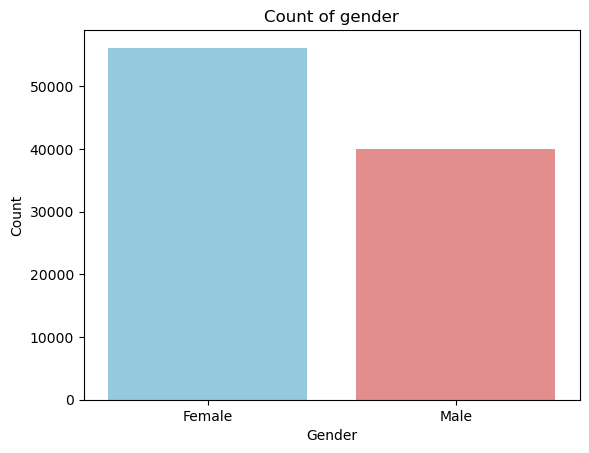

In [23]:

import seaborn as sns
import matplotlib.pyplot as plt

palette_colors = ['skyblue', 'lightcoral']  # สีฟ้า (No), สีแดงอ่อน (Yes)
sns.countplot(x='gender', data=dtt, palette=palette_colors)
plt.title('Count of gender') # ตั้งชื่อกราฟ
plt.xlabel('Gender')            # ชื่อแกน X
plt.ylabel('Count')                   # ชื่อแกน Y
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2950820360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_group', data=dtt, palette=palette_colors)
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2950820360.py:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='age_group', data=dtt, palette=palette_colors)


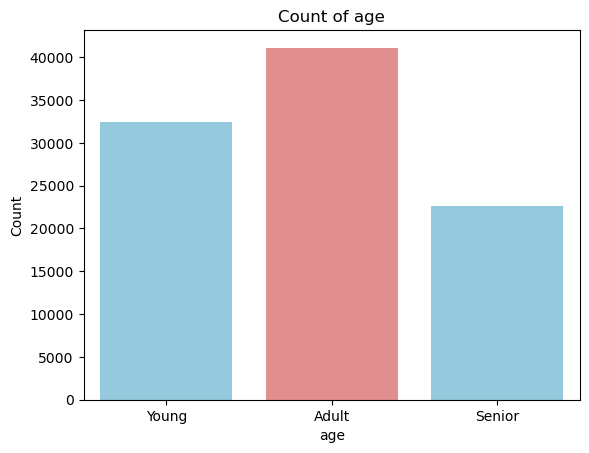

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

palette_colors = ['skyblue', 'lightcoral']  # สีฟ้า (No), สีแดงอ่อน (Yes)
sns.countplot(x='age_group', data=dtt, palette=palette_colors)
plt.title('Count of age') # ตั้งชื่อกราฟ
plt.xlabel('age')            # ชื่อแกน X
plt.ylabel('Count')                   # ชื่อแกน Y
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3668454703.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hypertension', data=dtt, palette=palette_colors)


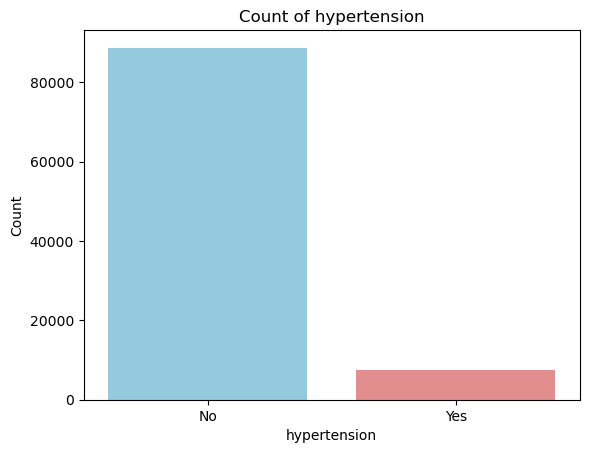

In [25]:
palette_colors = ['skyblue', 'lightcoral']  # สีฟ้า (No), สีแดงอ่อน (Yes)
sns.countplot(x='hypertension', data=dtt, palette=palette_colors)
plt.title('Count of hypertension') # ตั้งชื่อกราฟ
plt.xlabel('hypertension')            # ชื่อแกน X
plt.ylabel('Count')                   # ชื่อแกน Y
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3997956112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=dtt, palette=palette_colors)


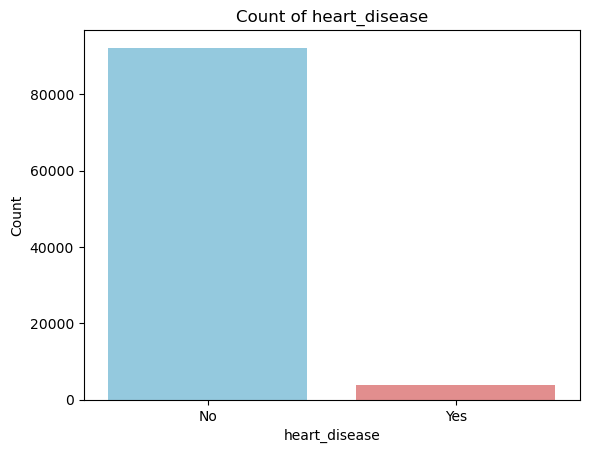

In [26]:
palette_colors = ['skyblue', 'lightcoral']  # สีฟ้า (No), สีแดงอ่อน (Yes)
sns.countplot(x='heart_disease', data=dtt, palette=palette_colors)
plt.title('Count of heart_disease') # ตั้งชื่อกราฟ
plt.xlabel('heart_disease')            # ชื่อแกน X
plt.ylabel('Count')                   # ชื่อแกน Y
plt.show()

#### ทำการจัดกลุ่มตัวแปร smoking ให้จาก จาก 6 กลุ่มให้เหลือเป็น 3  
#### กลุ่มเพื่อให้ง่ายต่อการวิเคราะห์

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2590163572.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoking_group', data=dtt, order=order_list, palette=palette_colors)


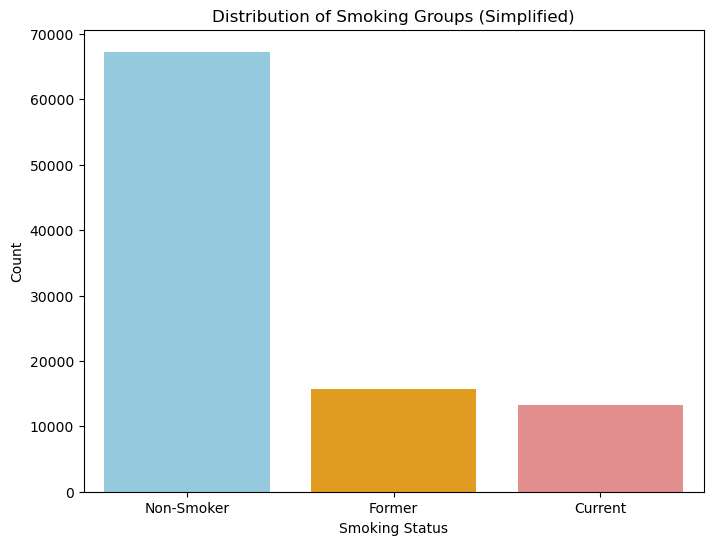

In [27]:
# 1. สร้างดิกชันนารีสำหรับเปลี่ยนชื่อกลุ่ม
smoking_map = {
    'never': 'Non-Smoker',
    'No Info': 'Non-Smoker',
    'current': 'Current',
    'ever': 'Current',
    'former': 'Former',
    'not current': 'Former'
}

# 2. ใช้คำสั่ง replace เพื่อสร้างคอลัมน์ใหม่
dtt['smoking_group'] = dtt['smoking_history'].replace(smoking_map)

# 3. พล็อตกราฟใหม่ (เหลือแค่ 3 แท่ง)
plt.figure(figsize=(8, 6))
# กำหนดลำดับให้ดูง่าย: ไม่สูบ -> เลิกแล้ว -> สูบอยู่
order_list = ['Non-Smoker', 'Former', 'Current']
palette_colors = ['skyblue', 'orange', 'lightcoral'] # ฟ้า, ส้ม, แดง

sns.countplot(x='smoking_group', data=dtt, order=order_list, palette=palette_colors)
plt.title('Distribution of Smoking Groups (Simplified)')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.show()

#### ทำการจัดกลุ่มตัวแปร bmi ให้ จาก 4 กลุ่ม ให้เหลือ 3 
#### กลุ่มเพื่อให้ง่ายต่อการวิเคราะห์

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\151191420.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bmi_group', data=dtt, palette=['skyblue', 'orange', 'lightcoral'])


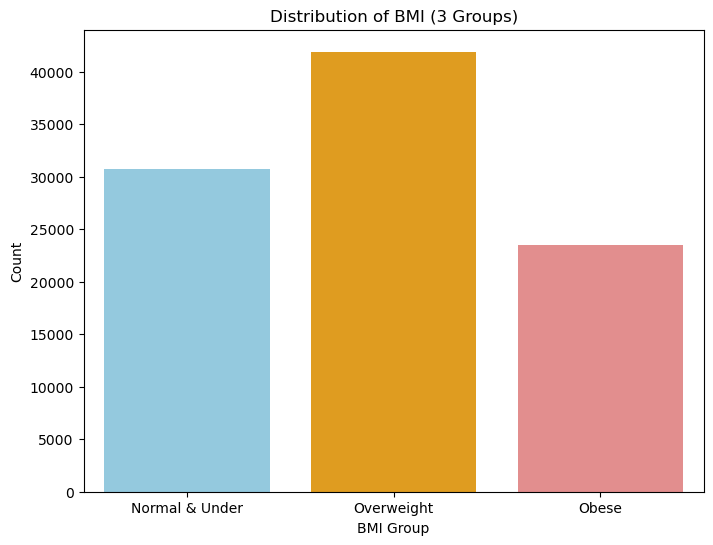

In [28]:
# กำหนดช่วงใหม่ (ยุบช่วงแรกเข้าด้วยกัน)
# 0-25 (Normal/Under), 25-30 (Overweight), 30+ (Obese)
bins_bmi_3 = [0, 25, 30, 100]
labels_bmi_3 = ['Normal & Under', 'Overweight', 'Obese']

# สร้างคอลัมน์ใหม่
dtt['bmi_group'] = pd.cut(dtt['bmi'], bins=bins_bmi_3, labels=labels_bmi_3, right=False)

# ลองพล็อตกราฟดูผลลัพธ์ (คราวนี้กราฟจะสมดุลขึ้นมากครับ)
plt.figure(figsize=(8, 6))
# ใช้ 3 สี: ฟ้า(ปกติ), ส้ม(ท้วม), แดง(อ้วน)
sns.countplot(x='bmi_group', data=dtt, palette=['skyblue', 'orange', 'lightcoral'])
plt.title('Distribution of BMI (3 Groups)')
plt.xlabel('BMI Group')
plt.ylabel('Count')
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3592372160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HbA1c_group', data=dtt, palette=palette_colors)
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3592372160.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='HbA1c_group', data=dtt, palette=palette_colors)


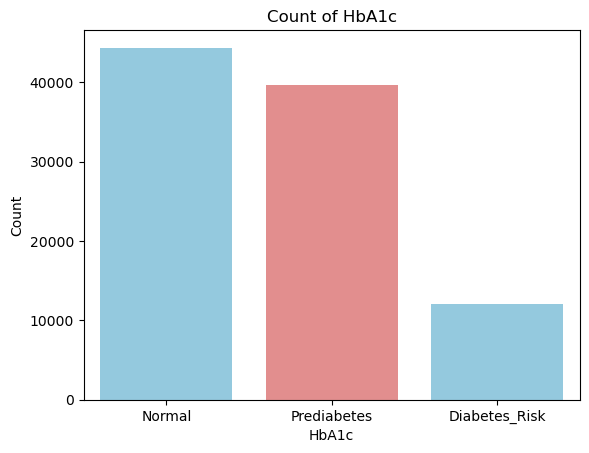

In [29]:
palette_colors = ['skyblue', 'lightcoral']  # สีฟ้า (No), สีแดงอ่อน (Yes)
sns.countplot(x='HbA1c_group', data=dtt, palette=palette_colors)
plt.title('Count of HbA1c') # ตั้งชื่อกราฟ
plt.xlabel('HbA1c')            # ชื่อแกน X
plt.ylabel('Count')                   # ชื่อแกน Y
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2160440087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='glucose_group', data=dtt, palette=palette_colors)
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2160440087.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='glucose_group', data=dtt, palette=palette_colors)


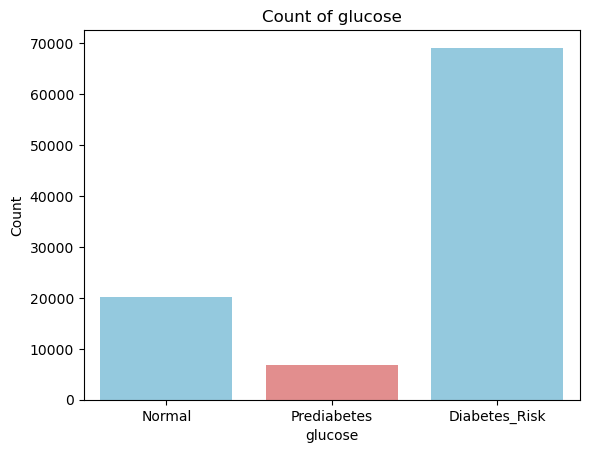

In [30]:
palette_colors = ['skyblue', 'lightcoral']  # สีฟ้า (No), สีแดงอ่อน (Yes)
sns.countplot(x='glucose_group', data=dtt, palette=palette_colors)
plt.title('Count of glucose') # ตั้งชื่อกราฟ
plt.xlabel('glucose')            # ชื่อแกน X
plt.ylabel('Count')                   # ชื่อแกน Y
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\1519458016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes', data=dtt, palette=palette_colors)


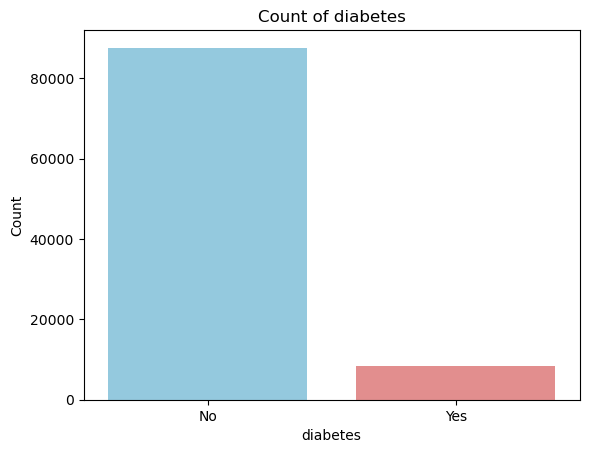

In [31]:
palette_colors = ['skyblue', 'lightcoral']  # สีฟ้า (No), สีแดงอ่อน (Yes)
sns.countplot(x='diabetes', data=dtt, palette=palette_colors)
plt.title('Count of diabetes') # ตั้งชื่อกราฟ
plt.xlabel('diabetes')            # ชื่อแกน X
plt.ylabel('Count')                   # ชื่อแกน Y
plt.show()

In [32]:
dtt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96128 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               96128 non-null  object  
 1   age                  96128 non-null  float64 
 2   hypertension         96128 non-null  category
 3   heart_disease        96128 non-null  category
 4   smoking_history      96128 non-null  object  
 5   bmi                  96128 non-null  float64 
 6   HbA1c_level          96128 non-null  float64 
 7   blood_glucose_level  96128 non-null  int64   
 8   diabetes             96128 non-null  category
 9   age_group            96128 non-null  category
 10  bmi_group            96128 non-null  category
 11  HbA1c_group          96128 non-null  category
 12  glucose_group        96128 non-null  category
 13  smoking_group        96128 non-null  object  
dtypes: category(7), float64(3), int64(1), object(3)
memory usage: 6.5+ MB


#### plot กราฟ Heatmap เพื่อดูความสัมพันธ์ระหว่างตัวแปรต้นและตัวแปรตาม

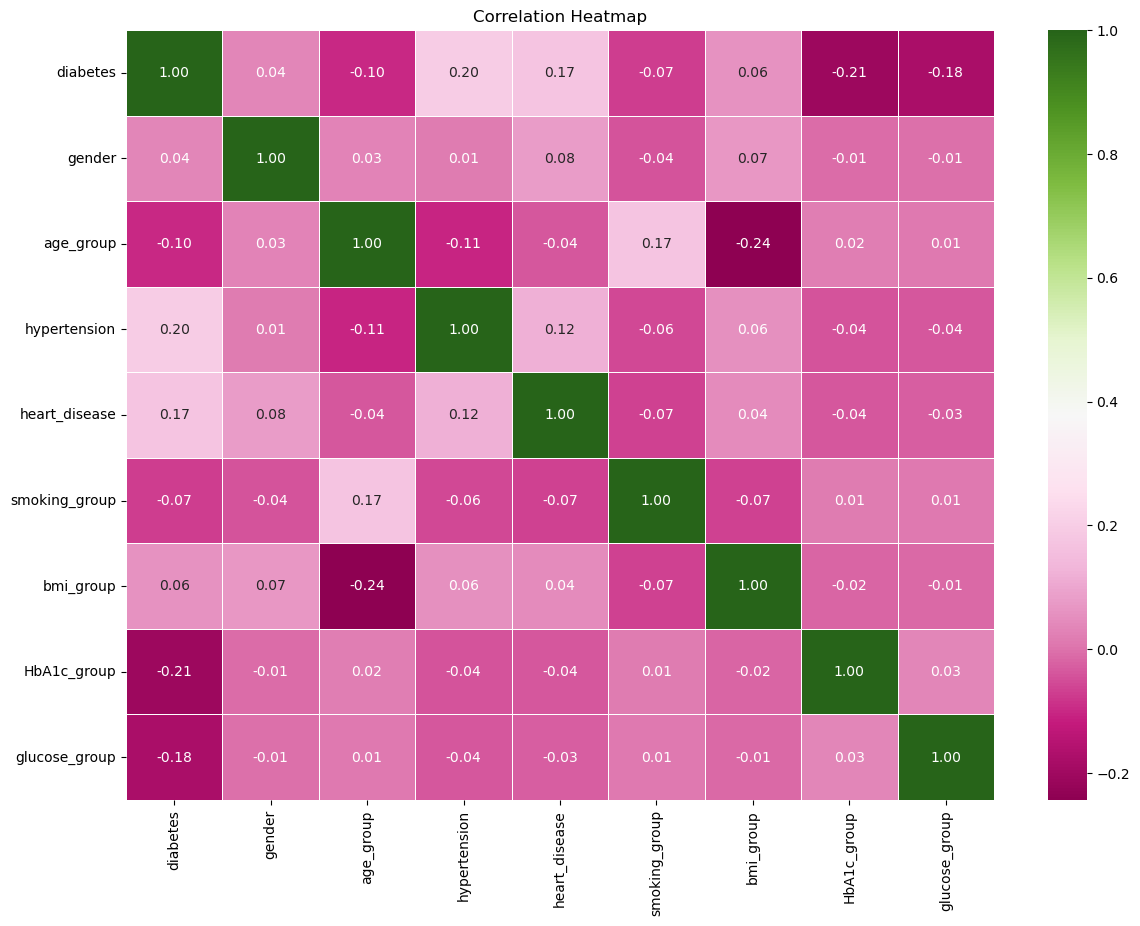

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from pandas.api.types import is_numeric_dtype

# คัดลอกคอลัมน์ที่ต้องการมา
columns_to_plot = ['diabetes','gender', 'age_group', 'hypertension', 'heart_disease', 'smoking_group', 'bmi_group', 'HbA1c_group', 'glucose_group']
data_to_plot = dtt[columns_to_plot].copy()

# --- ส่วนที่แก้ไขให้รัดกุมขึ้น ---
le = LabelEncoder()

for col in data_to_plot.columns:
    # เช็คว่าคอลัมน์นี้ "ไม่ใช่ตัวเลข" ใช่ไหม? (ครอบคลุมทั้ง Object, String, Category)
    if not is_numeric_dtype(data_to_plot[col]):
        # แปลงเป็น String ก่อนกันเหนียว แล้วค่อยแปลงเป็นตัวเลข
        data_to_plot[col] = le.fit_transform(data_to_plot[col].astype(str))
# -----------------------------

# พล็อตกราฟ
plt.figure(figsize=(14, 10))
sns.heatmap(data_to_plot.corr(), annot=True, cmap='PiYG', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#### ทำการแบ่งช่วง Train และ Test ให้โมเดล 
#### และทำการลบข้อมูลตัวแปรที่ได้ทำงานจัดกลุ่มใหม่ 

In [53]:

from sklearn.model_selection import train_test_split
# 1. กำหนดตัวแปรต้น (X) และตัวแปรตาม (y)
# --- แก้ไขตรงนี้: ลบ 'diabetes' และ "ตัวเลขดิบ" ที่ไม่ต้องการออกให้หมดครับ ---
cols_to_drop = ['diabetes', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'smoking_history']
X = dtt.drop(columns=cols_to_drop) 

y = dtt['diabetes']

# (สำคัญ) เนื่องจากตอนนี้ X เหลือแต่ "กลุ่ม" (ที่เป็นตัวหนังสือ) 
# ต้องแปลงเป็นตัวเลขก่อนแบ่งข้อมูลครับ ไม่งั้นเดี๋ยวไปรันโมเดลจะ Error
X = pd.get_dummies(X, drop_first=True)

# 2. แบ่งข้อมูลเป็น Train และ Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("แบ่งข้อมูลเรียบร้อยแล้วครับ!")
print(f"ตัวแปรที่ใช้ (Features): {X.columns.tolist()}") # เช็คดูได้เลยครับว่าเหลือแต่ _group แล้ว
print(f"จำนวนข้อมูลสอน (Train): {len(X_train)}")
print(f"จำนวนข้อมูลสอบ (Test): {len(X_test)}")

แบ่งข้อมูลเรียบร้อยแล้วครับ!
ตัวแปรที่ใช้ (Features): ['gender_Male', 'hypertension_Yes', 'heart_disease_Yes', 'age_group_Adult', 'age_group_Senior', 'bmi_group_Overweight', 'bmi_group_Obese', 'HbA1c_group_Prediabetes', 'HbA1c_group_Diabetes_Risk', 'glucose_group_Prediabetes', 'glucose_group_Diabetes_Risk', 'smoking_group_Former', 'smoking_group_Non-Smoker']
จำนวนข้อมูลสอน (Train): 76902
จำนวนข้อมูลสอบ (Test): 19226


#### สร้างโมเดล Decision Tree

In [35]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- ขั้นตอนที่ 1: แปลง y เป็นตัวเลข (0, 1) ---
# ต้องทำทั้ง y_train และ y_test ให้เหมือนกัน ไม่งั้นตอนวัดผลจะ Error ครับ
y_train = y_train.replace({'No': 0, 'Yes': 1}).astype(int)
y_test = y_test.replace({'No': 0, 'Yes': 1}).astype(int)

# --- ขั้นตอนที่ 2: แปลง X เป็นตัวเลข (One-Hot Encoding) ---
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# ***สำคัญมาก***: ต้องจัดเรียงคอลัมน์ X_test ให้ตรงกับ X_train เป๊ะๆ
# (ป้องกัน Error กรณีข้อมูล Test มีบางคอลัมน์ไม่ครบ)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- ขั้นตอนที่ 3: สร้างและฝึกโมเดล ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_encoded, y_train) # ใช้ X ที่ encode แล้ว

# --- ขั้นตอนที่ 4: ทำนายและวัดผล ---
y_pred_dt = dt.predict(X_test_encoded) # ใช้ X ที่ encode แล้ว

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9315510246541142

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     17525
           1       0.67      0.44      0.53      1701

    accuracy                           0.93     19226
   macro avg       0.81      0.71      0.75     19226
weighted avg       0.92      0.93      0.92     19226



C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2039803763.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'No': 0, 'Yes': 1}).astype(int)
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2039803763.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_train = y_train.replace({'No': 0, 'Yes': 1}).astype(int)
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\2039803763.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call 

#### plot กราฟแผนภาพต้นไม้ และ Roc Curve

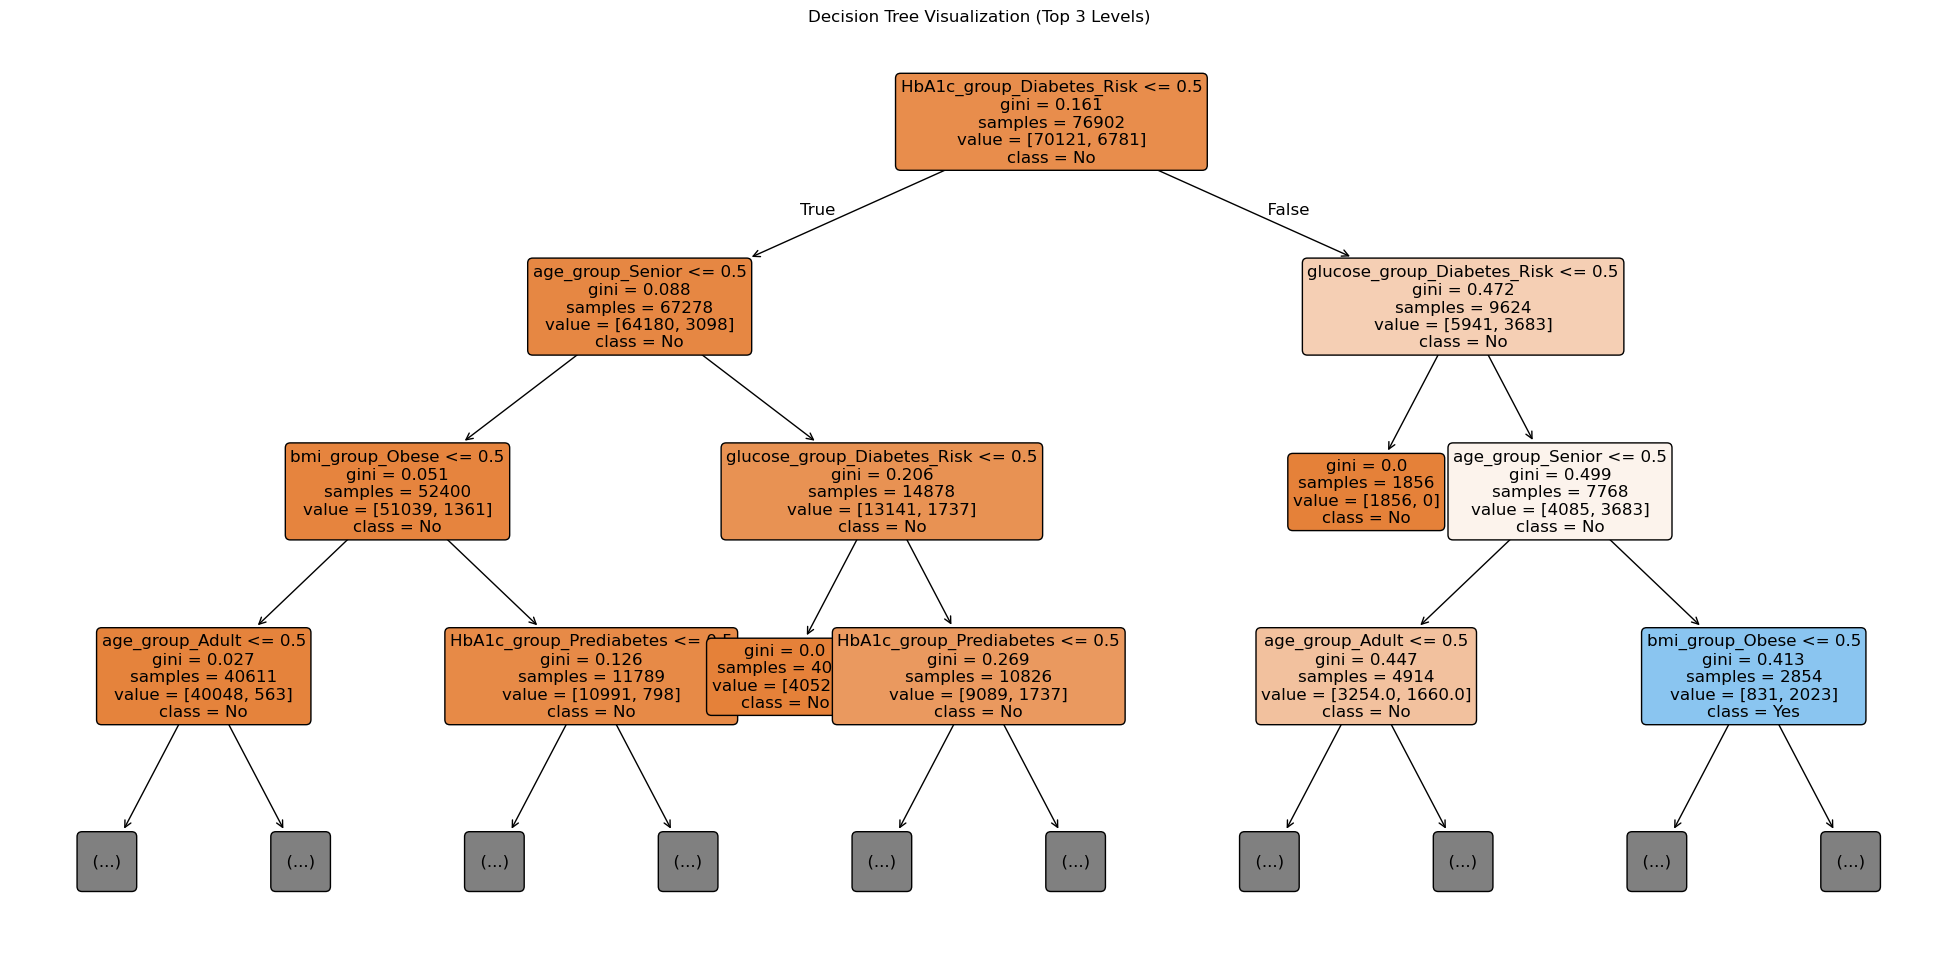

Decision Tree Accuracy: 0.9315510246541142


In [36]:
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. ต้องสั่งทำนายก่อนครับ (สร้างตัวแปร y_pred_dt)
# ใช้ X_test_encoded ที่เตรียมไว้แล้ว
y_pred_dt = dt.predict(X_test_encoded) 

# 2. พล็อตกราฟ (โค้ดเดิมของคุณ)
plt.figure(figsize=(25, 12))

plot_tree(dt, 
          feature_names=X_train_encoded.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=3)

plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.show()

# 3. วัดผล (ใช้ตัวแปร y_pred_dt ที่ถูกต้อง)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

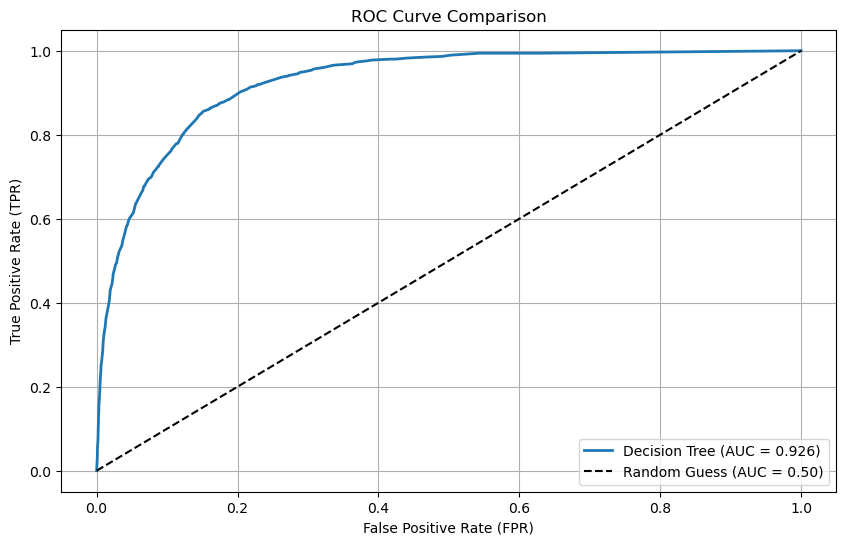

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# --- โมเดลที่ 1: Decision Tree (dt) ---
# ต้องใช้ .predict_proba() เพื่อเอาค่า "ความน่าจะเป็น" (Probability) ไม่ใช่แค่ 0 หรือ 1
# [:, 1] คือเอาเฉพาะความน่าจะเป็นที่จะเป็น 'Yes' (Class 1)
y_prob_dt = dt.predict_proba(X_test_encoded)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', linewidth=2)



# --- ตกแต่งกราฟ ---
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)') # เส้นประตรงกลาง (เดามั่ว)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### สร้างโมเดลKNN 

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler # เรียกใช้ Scaler

# ... (ส่วนที่ 1 และ 2 ของคุณทำมาดีแล้ว) ...

# --- เพิ่ม: 2.5 การปรับสเกลข้อมูล (Feature Scaling) ---
scaler = StandardScaler()

# Fit กับ Train และ Transform ทั้ง Train และ Test
# ต้องใช้ scaler ตัวเดิมที่ fit กับ train ไปใช้กับ test ด้วย เพื่อให้มาตรฐานเดียวกัน
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# --- 3. สร้างและฝึกโมเดล (ใช้ข้อมูลที่ Scale แล้ว) ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train) # ใช้ X_train_scaled แทน

# --- 4. ทำนายและวัดผล ---
y_pred_knn = knn.predict(X_test_scaled) # ใช้ X_test_scaled แทน

print("KNN Accuracy (Scaled):", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy (Scaled): 0.925205450951836

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     17525
           1       0.61      0.42      0.50      1701

    accuracy                           0.93     19226
   macro avg       0.78      0.70      0.73     19226
weighted avg       0.92      0.93      0.92     19226



#### plot Matrix และ Roc Curve

<Figure size 800x600 with 0 Axes>

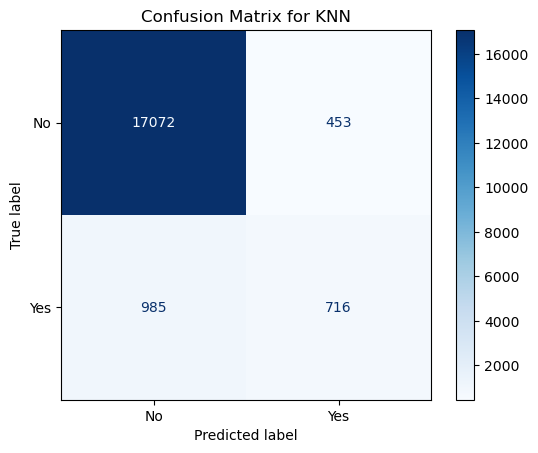

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. คำนวณ Confusion Matrix จาก y_pred_knn ที่ทำไปแล้ว
cm = confusion_matrix(y_test, y_pred_knn)

# 2. ตั้งค่าการแสดงผล
plt.figure(figsize=(8, 6))
# display_labels=['No', 'Yes'] คือเปลี่ยนเลข 0,1 ให้เป็นชื่อกลุ่ม
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

# 3. วาดกราฟ (cmap='Blues' คือโทนสีฟ้า)
disp.plot(cmap='Blues', values_format='d') 
plt.title('Confusion Matrix for KNN')
plt.show()

c:\Users\ACER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


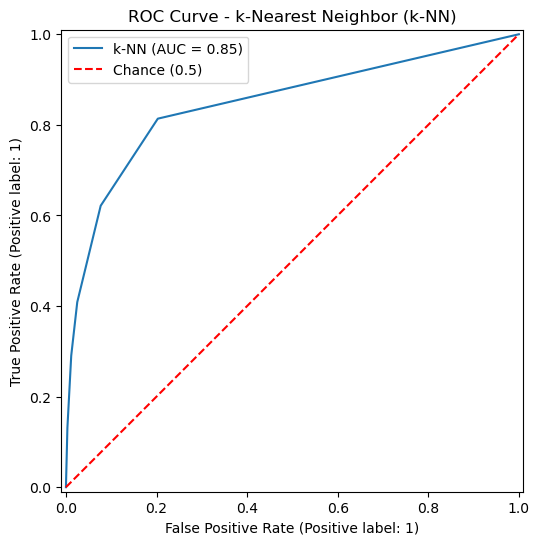

In [58]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# เปลี่ยนตัวแปรเป็น knn (สมมติว่าคุณตั้งชื่อตัวแปรโมเดลว่า knn)
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test, name='k-NN', ax=plt.gca())

# เส้นประสีแดง (เดามั่ว)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Chance (0.5)')

plt.title('ROC Curve - k-Nearest Neighbor (k-NN)')
plt.legend()
plt.show()

#### สร้างโมเดล Naive Bayes

In [56]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler # เรียกตัวช่วยปรับสเกล

# --- 1. แปลง y เป็นตัวเลข ---
y_train = y_train.replace({'No': 0, 'Yes': 1}).astype(int)
y_test = y_test.replace({'No': 0, 'Yes': 1}).astype(int)

# --- 2. แปลง X เป็นตัวเลข (One-Hot Encoding) ---
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# จัดคอลัมน์ให้ตรงกัน
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# --- 2.5 เพิ่มการปรับสเกล (สำคัญสำหรับ GaussianNB) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# --- 3. สร้างและฝึกโมเดล --- 
nb = GaussianNB()

# *** ใช้ข้อมูลที่ Scale แล้ว (X_train_scaled) มาสอนโมเดล ***
nb.fit(X_train_scaled, y_train) 

# --- 4. ทำนายและวัดผล ---
# *** ใช้ข้อมูลที่ Scale แล้ว (X_test_scaled) มาทำนาย ***
y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes Accuracy (Scaled):", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy (Scaled): 0.3679392489337356

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.31      0.47     17525
           1       0.12      1.00      0.22      1701

    accuracy                           0.37     19226
   macro avg       0.56      0.65      0.34     19226
weighted avg       0.92      0.37      0.45     19226



C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3078822331.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'No': 0, 'Yes': 1}).astype(int)
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3078822331.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_train = y_train.replace({'No': 0, 'Yes': 1}).astype(int)
C:\Users\ACER\AppData\Local\Temp\ipykernel_9024\3078822331.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call 

#### plot Matrix และ Roc Curve

<Figure size 800x600 with 0 Axes>

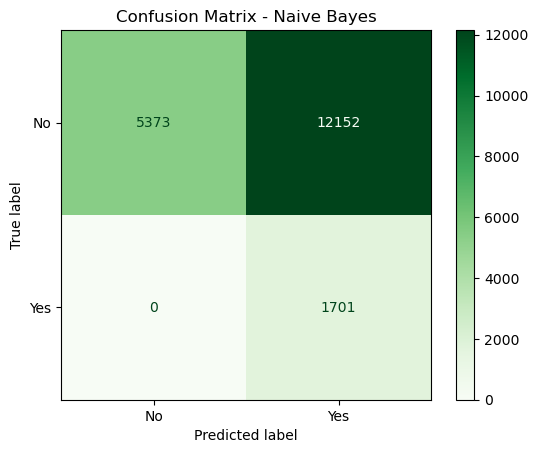

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# สร้าง Confusion Matrix
ConfusionMatrixDisplay.from_estimator(nb, X_test_scaled, y_test, 
                                      display_labels=['No', 'Yes'], 
                                      cmap='Greens')

plt.title('Confusion Matrix - Naive Bayes')
plt.show()

<Figure size 800x600 with 0 Axes>

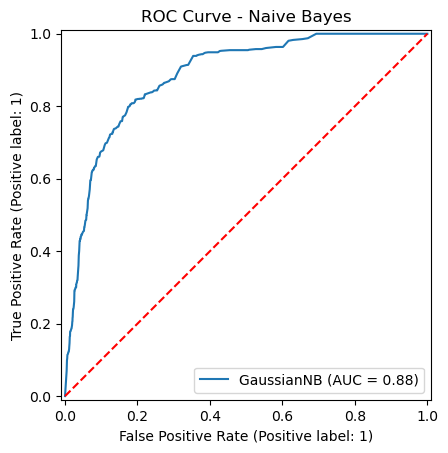

In [41]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# สร้างกราฟ ROC จากโมเดล nb ที่เทรนไว้แล้ว
RocCurveDisplay.from_estimator(nb, X_test_scaled, y_test)

# เพิ่มเส้นประสีแดง (เส้นเดามั่ว) เพื่อเทียบ
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Chance (0.5)')
plt.title('ROC Curve - Naive Bayes')
plt.show()

#### เปรียบเทียบค่า Accuracy ของ ทั้ง 3 โมเดล 

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd

# --- ส่วนที่ 1: สร้างและทำนายผลทั้ง 3 โมเดล ---

# 1. Decision Tree (ที่คุณมีอยู่แล้ว)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_encoded, y_train)
y_pred_dt = dt.predict(X_test_encoded)

# 2. KNN (ตัวที่ Error เพราะลืมรัน)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_encoded, y_train)
y_pred_knn = knn.predict(X_test_encoded)

# 3. Naive Bayes (ต้องรันด้วย ไม่งั้นบรรทัดสุดท้ายจะ Error)
nb = GaussianNB()
nb.fit(X_train_encoded, y_train)
y_pred_nb = nb.predict(X_test_encoded)

# --- ส่วนที่ 2: สร้างตารางเปรียบเทียบ ---
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ]
})

print(comparison)
 

           Model  Accuracy
0  Decision Tree  0.931551
1            KNN  0.924633
2    Naive Bayes  0.367939
